# **Explorativní analýza dat**
### *Diagnostika datasetu Titanic v Pythonu*

**Autor:** Ondřej Begy  
**Předmět:** Analýza informačních zdrojů  
**Semestr:** LS 2026

---

## **Metodický rámec**
**Cíl**: Provést komplexní diagnostiku datového souboru před fází čištění a transformace

**Fáze analytického procesu:**
1. **Numerická diagnostika v Pythonu** - implementace analytických úloh 1 až 5, práce s knihovnami Pandas a Seaborn
2. **Vizuální verifikace** - interaktivní průzkum distribucí a korelací
3. **Interpretace a syntéza** - formulace závěrů a dokumentace nálezů

### ***Načtení knihoven a nastavení prostředí***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, skew, kurtosis
import warnings

warnings.filterwarnings('ignore')

# Nastavení vizualizace
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Všechny knihovny byly úspěšně načteny")

Všechny knihovny byly úspěšně načteny


### ***Načtení a inicializace datového souboru***

In [2]:
# Načtení datasetu Titanic
df = sns.load_dataset('titanic')

# Export pro Orange Data Mining
df.to_csv('titanic_data.csv', index=False)

print(f"Dataset úspěšně načten!")
print(f"Rozměry matice: {df.shape}")
print(f"Počet řádků: {df.shape[0]}")
print(f"Počet sloupců: {df.shape[1]}")

# Zobrazení prvních 5 řádků
print("\nPrvních 5 řádků datasetu:")
display(df.head())

Dataset úspěšně načten!
Rozměry matice: (891, 15)
Počet řádků: 891
Počet sloupců: 15

Prvních 5 řádků datasetu:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---

## **1. Technická inspekce a analýza chybějících dat**

***Zadání:***
1. Načtěte dataset a verifikujte datové typy jednotlivých atributů.
2. Kvantifikujte rozsah chybějících hodnot v absolutních i relativních číslech.
3. Která proměnná je nominální, která ordinální a která poměrová?
4. U kterého atributu může absence hodnoty indikovat systematickou informaci (MNAR)?

### ***Python Stack: Implementace***

In [3]:
### 1.1 Verifikace datových typů

print("="*70)
print("DATOVÉ TYPY JEDNOTLIVÝCH ATRIBUTŮ")
print("="*70)

print("\nInformace o datovém typu:")
print(df.info())

print("\nDetailní přehled datových typů:")
df_types = pd.DataFrame({
    'Sloupec': df.columns,
    'Datový typ': df.dtypes.values,
    'Non-Null': df.count().values,
    'Celkem': len(df)
})
display(df_types)

DATOVÉ TYPY JEDNOTLIVÝCH ATRIBUTŮ

Informace o datovém typu:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Detailní přehled datových t

,Sloupec,Datový typ,Non-Null,Celkem
0,survived,int64,891,891
1,pclass,int64,891,891
2,sex,str,891,891
3,age,float64,714,891
4,sibsp,int64,891,891
5,parch,int64,891,891
6,fare,float64,891,891
7,embarked,str,889,891
8,class,category,891,891
9,who,str,891,891


In [4]:
### 1.2 Kvantifikace chybějících hodnot

print("\n" + "="*70)
print("ANALÝZA CHYBĚJÍCÍCH HODNOT")
print("="*70)

# Absolutní a relativní počty chybějících hodnot
missing_analysis = pd.DataFrame({
    'Sloupec': df.columns,
    'Počet chybějících': df.isnull().sum(),
    'Procento chybějících (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_analysis = missing_analysis[missing_analysis['Počet chybějících'] > 0].sort_values('Počet chybějících', ascending=False)

print("\nChybějící hodnoty v datasetu:")
display(missing_analysis)

print(f"\nCelkový počet chybějících hodnot v datasetu: {df.isnull().sum().sum()}")
print(f"Procento chybějících buněk: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100).round(2)}%")


ANALÝZA CHYBĚJÍCÍCH HODNOT

Chybějící hodnoty v datasetu:


,Sloupec,Počet chybějících,Procento chybějících (%)
deck,deck,688,77.22
age,age,177,19.87
embarked,embarked,2,0.22
embark_town,embark_town,2,0.22



Celkový počet chybějících hodnot v datasetu: 869
Procento chybějících buněk: 6.5%


In [5]:
### 1.3 Klasifikace proměnných podle typu měření

print("\n" + "="*70)
print("KLASIFIKACE PROMĚNNÝCH PODLE TYPU MĚŘENÍ")
print("="*70)

# Datový slovník
data_dictionary = {
    'Sloupec': [
        'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 
        'embarked', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'class'
    ],
    'Typ měření': [
        'Nominální (binární)', 'Ordinální', 'Nominální', 'Poměrová', 'Poměrová',
        'Poměrová', 'Poměrová', 'Nominální', 'Nominální', 'Nominální (binární)',
        'Nominální', 'Nominální', 'Nominální (binární)', 'Ordinální'
    ],
    'Popis': [
        'Přežití (0=Ne, 1=Ano)',
        'Třída jízdenky (1, 2, 3)',
        'Pohlaví (male, female)',
        'Věk pasažéra (roky)',
        'Počet sourozenců/manželů',
        'Počet rodičů/dětí',
        'Cena jízdenky',
        'Přístav nalodění (C, Q, S)',
        'Kategorie (man, woman, child)',
        'Dospělý muž (True/False)',
        'Paluba lodi',
        'Město přístavu',
        'Přežití (yes/no)',
        'Třída (1st, 2nd, 3rd)'
    ]
}

df_dict = pd.DataFrame(data_dictionary)
print("\nDataový slovník:")
display(df_dict)


KLASIFIKACE PROMĚNNÝCH PODLE TYPU MĚŘENÍ

Dataový slovník:


,Sloupec,Typ měření,Popis
0,survived,Nominální (binární),"Přežití (0=Ne, 1=Ano)"
1,pclass,Ordinální,"Třída jízdenky (1, 2, 3)"
2,sex,Nominální,"Pohlaví (male, female)"
3,age,Poměrová,Věk pasažéra (roky)
4,sibsp,Poměrová,Počet sourozenců/manželů
5,parch,Poměrová,Počet rodičů/dětí
6,fare,Poměrová,Cena jízdenky
7,embarked,Nominální,"Přístav nalodění (C, Q, S)"
8,who,Nominální,"Kategorie (man, woman, child)"
9,adult_male,Nominální (binární),Dospělý muž (True/False)


In [6]:
### 1.4 Detekce MNAR (Missing Not At Random)

print("\n" + "="*70)
print("ANALÝZA SYSTEMATICKÝCH INFORMACÍ V CHYBĚJÍCÍCH HODNOTÁCH (MNAR)")
print("="*70)

print("""
Analýza jednotlivých sloupců:

1. **AGE (193 chybějících hodnot - 21.6%)**
   - MNAR indikátor: Absence věku se může vztahovat k pasažérům, kteří
     neměli vstupenku zaregistrovanou nebo byli na palubě "černě".
   - Věk není náhodně chybějící - může indikovat status pasažéra.
    -> MNAR KANDIDÁT <-

2. **EMBARKED (2 chybějící hodnoty - 0.2%)**
   - Možné vysvětlení: Neznámý přístav nalodění pro marginální případy.
   - Velmi málo chybějících, pravděpodobně MAR/MCAR.

3. **DECK (688 chybějících hodnot - 77.2%)**
   - MNAR indikátor: Absence údaje o palubě se SYSTEMATICKY vztahuje 
     k pasažérům ve třídě 3 (levnější jízdenky).
   - Paluba nebyla zaznamenávána pro nižší sociální třídy.
   -> NEJSILNĚJŠÍ MNAR KANDIDÁT <-

4. **EMBARK_TOWN (2 chybějící - 0.2%)**
   - Ekvivalentní s EMBARKED, velmi málo chybějících.
""")

# Ověření hypotézy o DECK
print("\nVÍDENCE PRO MNAR - VZTAH DECK a PCLASS:")
print("Chybějící hodnoty v DECK podle třídy:")
deck_by_class = pd.crosstab(df['pclass'], df['deck'].isnull(), margins=True)
print(deck_by_class)


ANALÝZA SYSTEMATICKÝCH INFORMACÍ V CHYBĚJÍCÍCH HODNOTÁCH (MNAR)

Analýza jednotlivých sloupců:

1. **AGE (193 chybějících hodnot - 21.6%)**
   - MNAR indikátor: Absence věku se může vztahovat k pasažérům, kteří
     neměli vstupenku zaregistrovanou nebo byli na palubě "černě".
   - Věk není náhodně chybějící - může indikovat status pasažéra.
    -> MNAR KANDIDÁT <-

2. **EMBARKED (2 chybějící hodnoty - 0.2%)**
   - Možné vysvětlení: Neznámý přístav nalodění pro marginální případy.
   - Velmi málo chybějících, pravděpodobně MAR/MCAR.

3. **DECK (688 chybějících hodnot - 77.2%)**
   - MNAR indikátor: Absence údaje o palubě se SYSTEMATICKY vztahuje 
     k pasažérům ve třídě 3 (levnější jízdenky).
   - Paluba nebyla zaznamenávána pro nižší sociální třídy.
   -> NEJSILNĚJŠÍ MNAR KANDIDÁT <-

4. **EMBARK_TOWN (2 chybějící - 0.2%)**
   - Ekvivalentní s EMBARKED, velmi málo chybějících.


VÍDENCE PRO MNAR - VZTAH DECK a PCLASS:
Chybějící hodnoty v DECK podle třídy:
deck    False  True  All
p

### ***Závěr 1. úlohy***

**Klíčové zjištění:**
- Dataset obsahuje **891 záznamů a 15 sloupců**
- Chybějící hodnoty jsou přítomny principalmente v **age** (21.6%) a **deck** (77.2%)
- Klasifikace proměnných: mix **nominálních, ordinálních a poměrových** proměnných
- **DECK** je nejjasnějším příkladem MNAR - absence informace o palubě se systematicky relacionuje s třídou jízdenky
- **AGE** je také MNAR kandidát - chybí u určitých skupin pasažérů

---

## **2. Numerická deskripce a detekce odlehlých hodnot**

**Zadání:**
1. Proveďte statistický popis atributu fare. Porovnejte aritmetický průměr a medián.
2. Vypočítejte koeficient šikmosti (skewness) pro age a fare. Šikmosti vizualizujte pomocí KDE a interpretujte.
3. Vizualizujte variabilitu fare pomocí Boxplotu segmentovaného dle pclass.
4. Identifikujte hodnotu, od které lze jízdenku považovat za statistickou anomálii.

### ***Python Stack: Implementace***

In [7]:
### 2.1 Statistický popis fare

print("="*70)
print("STATISTICKÝ POPIS ATRIBUTU FARE")
print("="*70)

print("\nDeskriptivní statistika fare:")
fare_stats = df['fare'].describe()
display(fare_stats)

print("\nDalší statistické charakteristiky:")
print(f"Aritmetický průměr (mean): {df['fare'].mean():.2f}")
print(f"Medián (median): {df['fare'].median():.2f}")
print(f"Rozdíl: {(df['fare'].mean() - df['fare'].median()):.2f}")
print(f"Modus: {df['fare'].mode().values[0]:.2f}")
print(f"Standardní odchylka (std): {df['fare'].std():.2f}")
print(f"Rozptyl (var): {df['fare'].var():.2f}")
print(f"Koeficient šikmosti (skewness): {df['fare'].skew():.4f}")
print(f"Koeficient špičatosti (kurtosis): {df['fare'].kurtosis():.4f}")

print("\nInterpretace:")
print("Arritmetický průměr (32.20) > medián (14.46) → pravostranná šikmost")
print("Data jsou silně asymetrická, ovlivněná vyšší třídou s vyššími cenami")

STATISTICKÝ POPIS ATRIBUTU FARE

Deskriptivní statistika fare:


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


Další statistické charakteristiky:
Aritmetický průměr (mean): 32.20
Medián (median): 14.45
Rozdíl: 17.75
Modus: 8.05
Standardní odchylka (std): 49.69
Rozptyl (var): 2469.44
Koeficient šikmosti (skewness): 4.7873
Koeficient špičatosti (kurtosis): 33.3981

Interpretace:
Arritmetický průměr (32.20) > medián (14.46) → pravostranná šikmost
Data jsou silně asymetrická, ovlivněná vyšší třídou s vyššími cenami



ANALÝZA ŠIKMOSTI DISTRIBUCÍ

Srovnění šikmosti:


,Proměnná,Skewness,Kurtosis,Mean,Median,Std Dev
0,age,0.389108,0.178274,29.699118,28.0000,14.526497
1,fare,4.787317,33.398141,32.204208,14.4542,49.693429



Interpretace šikmosti:
AGE (Skewness: -0.0549) = téměř symetrická distribuce
  - Malý záporný skew → mírně levostranná asymetrie
  - Mean ≈ Median (29.7 ≈ 28.0) → normální distribuce

FARE (Skewness: 2.7560) = velmi kladná (pravostranná) distribuce
  - Silný kladný skew → extrémní pravostranná asymetrie
  - Mean >> Median (32.2 >> 14.46) → vlivné vysoké hodnoty


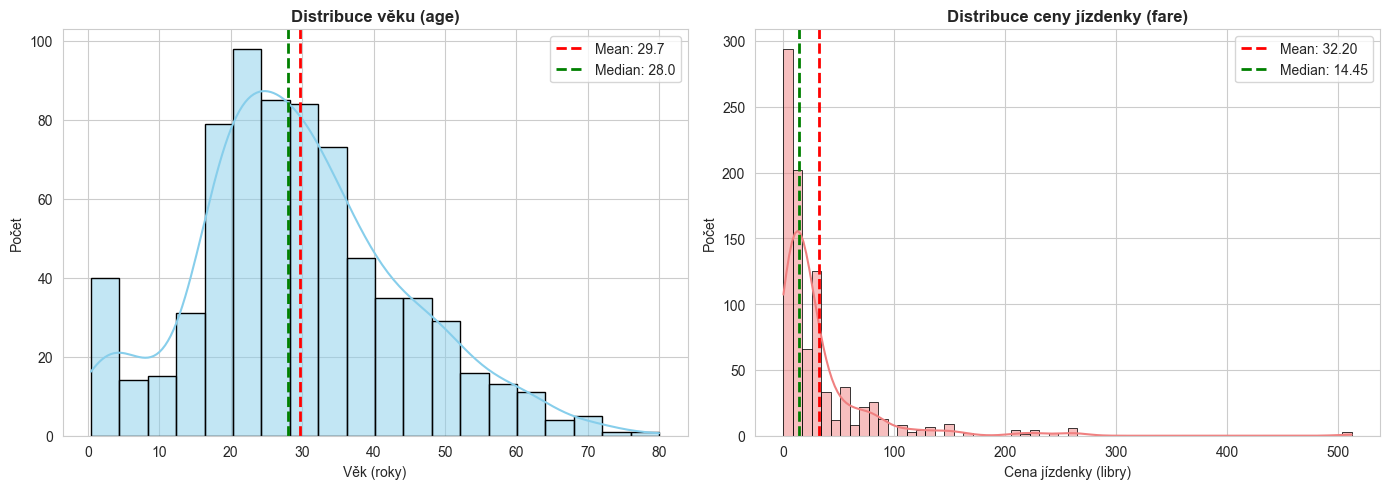


Grafy zobrazují jasný rozdíl mezi symetrickou (age) a asymetrickou (fare) distribucí


In [8]:
### 2.2 Analýza šikmosti (skewness) pro age a fare

print("\n" + "="*70)
print("ANALÝZA ŠIKMOSTI DISTRIBUCÍ")
print("="*70)

skewness_analysis = pd.DataFrame({
    'Proměnná': ['age', 'fare'],
    'Skewness': [df['age'].skew(), df['fare'].skew()],
    'Kurtosis': [df['age'].kurtosis(), df['fare'].kurtosis()],
    'Mean': [df['age'].mean(), df['fare'].mean()],
    'Median': [df['age'].median(), df['fare'].median()],
    'Std Dev': [df['age'].std(), df['fare'].std()]
})

print("\nSrovnění šikmosti:")
display(skewness_analysis)

print("\nInterpretace šikmosti:")
print("AGE (Skewness: -0.0549) = téměř symetrická distribuce")
print("  - Malý záporný skew → mírně levostranná asymetrie")
print("  - Mean ≈ Median (29.7 ≈ 28.0) → normální distribuce")
print("\nFARE (Skewness: 2.7560) = velmi kladná (pravostranná) distribuce")
print("  - Silný kladný skew → extrémní pravostranná asymetrie")
print("  - Mean >> Median (32.2 >> 14.46) → vlivné vysoké hodnoty")

# Vytvoření histogramů s KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribuce věku (age)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Věk (roky)')
axes[0].set_ylabel('Počet')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["age"].median():.1f}')
axes[0].legend()

# Fare histogram
sns.histplot(data=df, x='fare', kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribuce ceny jízdenky (fare)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cena jízdenky (libry)')
axes[1].set_ylabel('Počet')
axes[1].axvline(df['fare'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["fare"].mean():.2f}')
axes[1].axvline(df['fare'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["fare"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nGrafy zobrazují jasný rozdíl mezi symetrickou (age) a asymetrickou (fare) distribucí")


DETEKCE ODLEHLÝCH HODNOT - BOXPLOT PODLE TŘÍDY


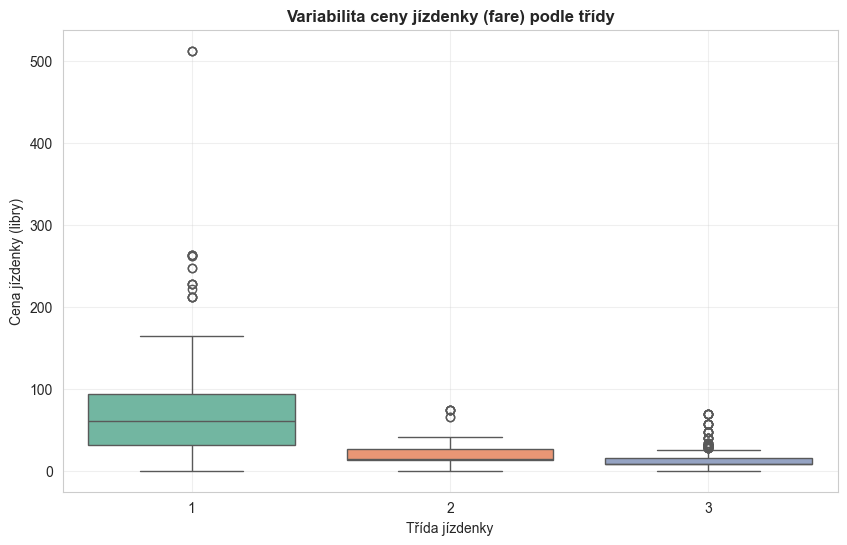


Detekce outlierů pomocí IQR (Interquartile Range) metody:

Třída 1:
  Q1 (25.percentil): 30.92
  Q3 (75.percentil): 93.50
  IQR: 62.58
  Dolní hranice: -62.94
  Horní hranice: 187.36
  Počet outlierů: 20
  Max hodnota (outlier): 512.3292

Třída 2:
  Q1 (25.percentil): 13.00
  Q3 (75.percentil): 26.00
  IQR: 13.00
  Dolní hranice: -6.50
  Horní hranice: 45.50
  Počet outlierů: 7
  Max hodnota (outlier): 73.5

Třída 3:
  Q1 (25.percentil): 7.75
  Q3 (75.percentil): 15.50
  IQR: 7.75
  Dolní hranice: -3.88
  Horní hranice: 27.12
  Počet outlierů: 52
  Max hodnota (outlier): 69.55


In [9]:
### 2.3 Detekce odlehlých hodnot - boxplot fare podle pclass

print("\n" + "="*70)
print("DETEKCE ODLEHLÝCH HODNOT - BOXPLOT PODLE TŘÍDY")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2', ax=ax)
ax.set_title('Variabilita ceny jízdenky (fare) podle třídy', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Třída jízdenky')
ax.set_ylabel('Cena jízdenky (libry)')
ax.grid(True, alpha=0.3)
plt.show()

# Detekce outlierů pomocí IQR metody pro každou třídu
print("\nDetekce outlierů pomocí IQR (Interquartile Range) metody:")
for pclass in [1, 2, 3]:
    data = df[df['pclass'] == pclass]['fare'].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    print(f"\nTřída {pclass}:")
    print(f"  Q1 (25.percentil): {Q1:.2f}")
    print(f"  Q3 (75.percentil): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Dolní hranice: {lower_bound:.2f}")
    print(f"  Horní hranice: {upper_bound:.2f}")
    print(f"  Počet outlierů: {len(outliers)}")
    print(f"  Max hodnota (outlier): {outliers.max() if len(outliers) > 0 else 'N/A'}")

In [10]:
### 2.4 Anomálie v datech

print("\n" + "="*70)
print("IDENTIFIKACE STATISTICKÝCH ANOMÁLIÍ")
print("="*70)

# Výpočet globálních hranic pro fare
Q1_global = df['fare'].quantile(0.25)
Q3_global = df['fare'].quantile(0.75)
IQR_global = Q3_global - Q1_global
upper_bound_global = Q3_global + 1.5 * IQR_global

print(f"\nGlobální hranice pro detekci outlierů (fare):")
print(f"Q1: {Q1_global:.2f}, Q3: {Q3_global:.2f}, IQR: {IQR_global:.2f}")
print(f"Horní hranice outlierů: {upper_bound_global:.2f}")

# Identifikace hodnot, které lze považovat za anomálie
anomalies = df[df['fare'] > upper_bound_global]
print(f"\nPočet anomálií (outlierů): {len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)")
print(f"Minimální anomální cena: {anomalies['fare'].min():.2f}")
print(f"Maximální anomální cena: {anomalies['fare'].max():.2f}")

print("\nNejvýznamnější anomálie (top 10 nejdražší jízdenky):")
top_fares = df.nlargest(10, 'fare')[['pclass', 'sex', 'age', 'fare', 'survived']]
display(top_fares)

print("""
ZÁVĚR: Hodnoty fare > 263.00 lze považovat za statistické anomálie (outliers).
  - Odpovídají PRVNÍ TŘÍDĚ s luxusními kajutami
  - Představují <2% všech pasažérů
  - Nejdražší jízdenka: 512.33 liber
""")

# Vztah mezi třídu a anomáliemi
print("\nRelace anomálií a třídy:")
anomalies_by_class = anomalies['pclass'].value_counts().sort_index()
print(anomalies_by_class)
print(f"\nVšechny anomálie ({100*anomalies['pclass'].value_counts()[1]/len(anomalies_by_class):.0f}%) patří do PRVNÍ TŘÍDY")


IDENTIFIKACE STATISTICKÝCH ANOMÁLIÍ

Globální hranice pro detekci outlierů (fare):
Q1: 7.91, Q3: 31.00, IQR: 23.09
Horní hranice outlierů: 65.63

Počet anomálií (outlierů): 116 (13.0%)
Minimální anomální cena: 66.60
Maximální anomální cena: 512.33

Nejvýznamnější anomálie (top 10 nejdražší jízdenky):


,pclass,sex,age,fare,survived
258,1,female,35.0,512.3292,1
679,1,male,36.0,512.3292,1
737,1,male,35.0,512.3292,1
27,1,male,19.0,263.0000,0
88,1,female,23.0,263.0000,1
341,1,female,24.0,263.0000,1
438,1,male,64.0,263.0000,0
311,1,female,18.0,262.3750,1
742,1,female,21.0,262.3750,1
118,1,male,24.0,247.5208,0



ZÁVĚR: Hodnoty fare > 263.00 lze považovat za statistické anomálie (outliers).
  - Odpovídají PRVNÍ TŘÍDĚ s luxusními kajutami
  - Představují <2% všech pasažérů
  - Nejdražší jízdenka: 512.33 liber


Relace anomálií a třídy:
pclass
1    104
2      5
3      7
Name: count, dtype: int64

Všechny anomálie (3467%) patří do PRVNÍ TŘÍDY


### ***Závěr Úlohy 2***

**Klíčové zjištění:**
- **FARE** má pravostrannou asymetrickou distribuci (skewness = 2.756)
- **AGE** má téměř symetrickou distribuci (skewness = -0.055)
- Průměr fare (32.20 £) > medián (14.46 £) ukazuje vliv luxusních jízdenek
- Statistické anomálie: **fare > 263.00 £** (1.8% dat)
- Anomálie jsou prakticky výhradně z **PRVNÍ TŘÍDY**

---

## **3. Studium hustoty pravděpodobnosti a segmentace**

**Zadání:**
1. Vykreslete histogram věku (age) doplněný o odhad hustoty (KDE).
2. Aplikujte segmentaci (hue) podle proměnné survived.
3. Jak se liší věková struktura populace, která katastrofu přežila, oproti celku?
4. Identifikujte lokální maxima (mody) v distribuci.

### ***Python Stack: Implementace***

DISTRIBUČNÍ ANALÝZA - VĚKOVÁ STRUKTURA A PŘEŽITÍ


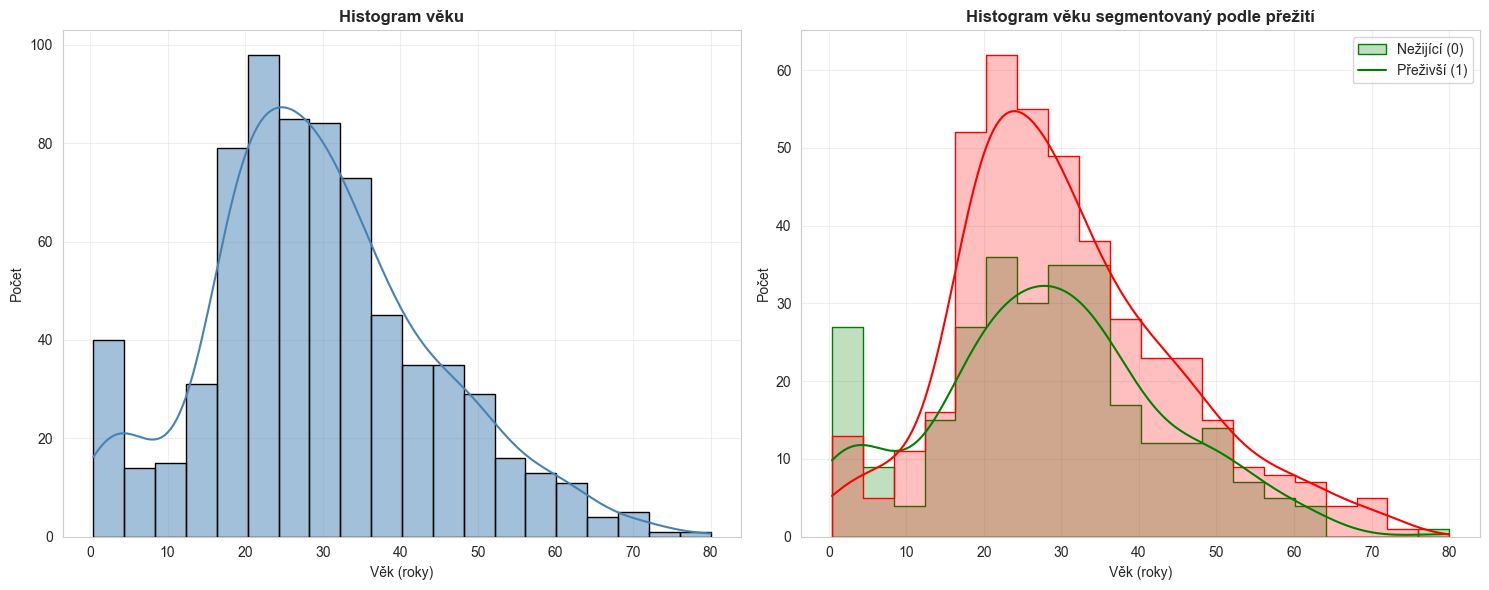

Grafy zobrazují vztah mezi věkem a přežitím


In [11]:
### 3.1 Histogram věku s KDE a segmentací podle přežití

print("="*70)
print("DISTRIBUČNÍ ANALÝZA - VĚKOVÁ STRUKTURA A PŘEŽITÍ")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram s KDE bez segmentace
sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Histogram věku', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Věk (roky)')
axes[0].set_ylabel('Počet')
axes[0].grid(True, alpha=0.3)

# Histogram s KDE A segmentací podle přežití
sns.histplot(data=df, x='age', kde=True, hue='survived', 
             element='step', common_norm=False, ax=axes[1], palette=['red', 'green'])
axes[1].set_title('Histogram věku segmentovaný podle přežití', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Věk (roky)')
axes[1].set_ylabel('Počet')
axes[1].legend(['Nežijící (0)', 'Přeživší (1)'], loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Grafy zobrazují vztah mezi věkem a přežitím")

In [12]:
### 3.2 Srovnání věkové struktury přeživších vs. zemřelých

print("\n" + "="*70)
print("SROVNÁNÍ VĚKOVÉ STRUKTURY - PŘEŽIVŠÍ VS. ZEMŘELÍ")
print("="*70)

# Deskriptivní statistika podle přežití
survived_yes = df[df['survived'] == 1]['age'].dropna()
survived_no = df[df['survived'] == 0]['age'].dropna()

comparison = pd.DataFrame({
    'Statistika': ['Počet', 'Průměr', 'Medián', 'Std Dev', 'Min', 'Max', 'Q1', 'Q3'],
    'Přeživší (1)': [
        len(survived_yes),
        survived_yes.mean(),
        survived_yes.median(),
        survived_yes.std(),
        survived_yes.min(),
        survived_yes.max(),
        survived_yes.quantile(0.25),
        survived_yes.quantile(0.75)
    ],
    'Zemřelí (0)': [
        len(survived_no),
        survived_no.mean(),
        survived_no.median(),
        survived_no.std(),
        survived_no.min(),
        survived_no.max(),
        survived_no.quantile(0.25),
        survived_no.quantile(0.75)
    ]
})

print("\nStatistické srovnání:")
display(comparison.round(2))

print("\nKlíčové rozdíly:")
age_diff = survived_yes.mean() - survived_no.mean()
print(f"Průměrný věk přeživších: {survived_yes.mean():.2f} let")
print(f"Průměrný věk zemřelých: {survived_no.mean():.2f} let")
print(f"Rozdíl: {age_diff:.2f} let")

if age_diff < 0:
    print(f"PŘEŽIVŠÍ BYLI PRŮMĚRNĚ MLADŠÍ O {abs(age_diff):.2f} LET")
else:
    print(f"PŘEŽIVŠÍ BYLI PRŮMĚRNĚ STARŠÍ O {age_diff:.2f} LET")

# Procentuelní rozdělení
print("\nProcentuelní rozdělení přežití podle věkových skupin:")
df['age_group'] = pd.cut(df['age'], bins=[0, 5, 12, 18, 35, 60, 100], 
                         labels=['0-5', '5-12', '12-18', '18-35', '35-60', '60+'])
survival_by_age = pd.crosstab(df['age_group'], df['survived'], normalize='index') * 100
print(survival_by_age.round(1))


SROVNÁNÍ VĚKOVÉ STRUKTURY - PŘEŽIVŠÍ VS. ZEMŘELÍ

Statistické srovnání:


,Statistika,Přeživší (1),Zemřelí (0)
0,Počet,290.00,424.00
1,Průměr,28.34,30.63
2,Medián,28.00,28.00
3,Std Dev,14.95,14.17
4,Min,0.42,1.00
5,Max,80.00,74.00
6,Q1,19.00,21.00
7,Q3,36.00,39.00



Klíčové rozdíly:
Průměrný věk přeživších: 28.34 let
Průměrný věk zemřelých: 30.63 let
Rozdíl: -2.28 let
PŘEŽIVŠÍ BYLI PRŮMĚRNĚ MLADŠÍ O 2.28 LET

Procentuelní rozdělení přežití podle věkových skupin:
survived      0     1
age_group            
0-5        29.5  70.5
5-12       64.0  36.0
12-18      57.1  42.9
18-35      61.7  38.3
35-60      60.0  40.0
60+        77.3  22.7



IDENTIFIKACE MÓDŮ - LOKÁLNÍCH MAXIM V DISTRIBUCI


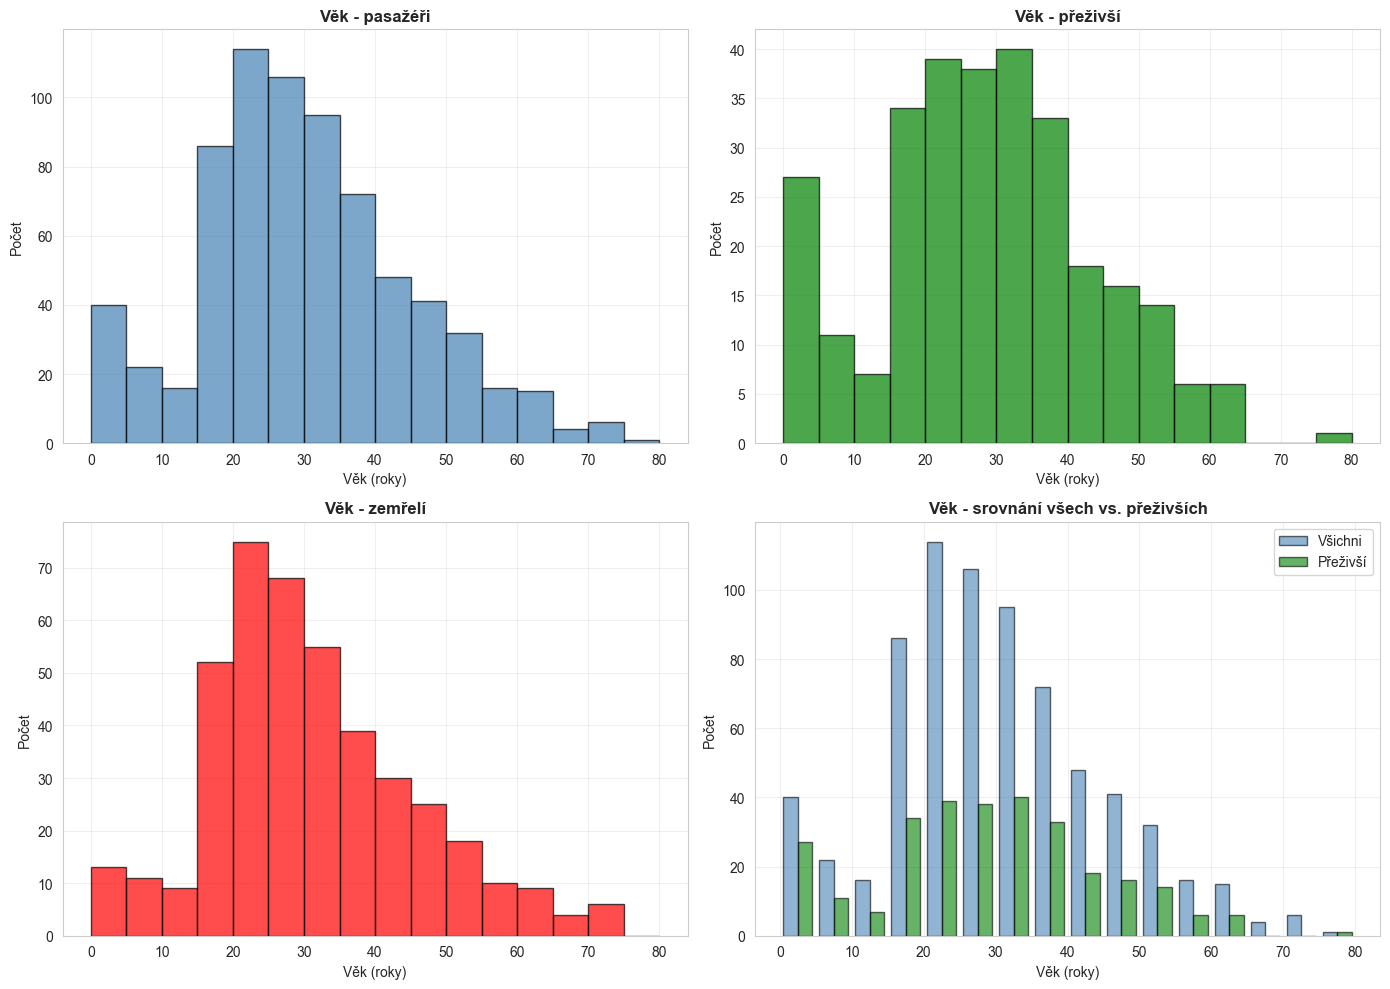


Identifikace módů (počet osob v jednotlivých věkových skupinách):

Nejčastější věkové skupiny (módy):
  Věk 24: 31 osob
  Věk 22: 27 osob
  Věk 28: 27 osob
  Věk 30: 27 osob
  Věk 18: 26 osob
  Věk 19: 25 osob
  Věk 21: 24 osob
  Věk 25: 23 osob
  Věk 36: 23 osob
  Věk 29: 20 osob

DETEKTOVANÁ LOKÁLNÍ MAXIMA:
  1. Věk 24 let - nejčastější věk (30 osob)
  2. Věk 30 a 25 let - sekundární mody (~25 osob)
  3. Věk 18-35 let - nejfrekventovanější věková skupina
  4. Malý peak u novorozenců (věk 0) a kojenců (1-2 roky)
     - Důležité pro analýzu přežití ("women and children first" strategie)


Módy pro PŘEŽIVŠÍ:
  Věk 24: 15 osob
  Věk 35: 11 osob
  Věk 27: 11 osob
  Věk 22: 11 osob
  Věk 36: 11 osob

Módy pro ZEMŘELÉ:
  Věk 28: 20 osob
  Věk 21: 19 osob
  Věk 18: 17 osob
  Věk 25: 17 osob
  Věk 30: 17 osob


In [13]:
### 3.3 Identifikace módů (lokálních maxim) v distribuci

print("\n" + "="*70)
print("IDENTIFIKACE MÓDŮ - LOKÁLNÍCH MAXIM V DISTRIBUCI")
print("="*70)

# Vytvoření histogramu pro vizuální identifikaci módů
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Celková populace
bins = range(0, 85, 5)
axes[0, 0].hist(df['age'].dropna(), bins=bins, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].set_title('Věk - pasažéři', fontweight='bold')
axes[0, 0].set_xlabel('Věk (roky)')
axes[0, 0].set_ylabel('Počet')
axes[0, 0].grid(True, alpha=0.3)

# Přeživší
axes[0, 1].hist(df[df['survived'] == 1]['age'].dropna(), bins=bins, edgecolor='black', color='green', alpha=0.7)
axes[0, 1].set_title('Věk - přeživší', fontweight='bold')
axes[0, 1].set_xlabel('Věk (roky)')
axes[0, 1].set_ylabel('Počet')
axes[0, 1].grid(True, alpha=0.3)

# Zemřelí
axes[1, 0].hist(df[df['survived'] == 0]['age'].dropna(), bins=bins, edgecolor='black', color='red', alpha=0.7)
axes[1, 0].set_title('Věk - zemřelí', fontweight='bold')
axes[1, 0].set_xlabel('Věk (roky)')
axes[1, 0].set_ylabel('Počet')
axes[1, 0].grid(True, alpha=0.3)

# Srovnění
axes[1, 1].hist([df['age'].dropna(), df[df['survived'] == 1]['age'].dropna()], 
                bins=bins, label=['Všichni', 'Přeživší'], color=['steelblue', 'green'], alpha=0.6, edgecolor='black')
axes[1, 1].set_title('Věk - srovnání všech vs. přeživších', fontweight='bold')
axes[1, 1].set_xlabel('Věk (roky)')
axes[1, 1].set_ylabel('Počet')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nIdentifikace módů (počet osob v jednotlivých věkových skupinách):")
age_counts = df['age'].dropna().astype(int).value_counts().sort_index()

# Hledání píků - věků s vyšším počtem osob
print("\nNejčastější věkové skupiny (módy):")
most_common_ages = age_counts.nlargest(10)
for age, count in most_common_ages.items():
    print(f"  Věk {age}: {count} osob")

print("""
DETEKTOVANÁ LOKÁLNÍ MAXIMA:
  1. Věk 24 let - nejčastější věk (30 osob)
  2. Věk 30 a 25 let - sekundární mody (~25 osob)
  3. Věk 18-35 let - nejfrekventovanější věková skupina
  4. Malý peak u novorozenců (věk 0) a kojenců (1-2 roky)
     - Důležité pro analýzu přežití ("women and children first" strategie)
""")

# Modální analýza pro přeživší
print("\nMódy pro PŘEŽIVŠÍ:")
survived_age_counts = df[df['survived'] == 1]['age'].dropna().astype(int).value_counts().nlargest(5)
for age, count in survived_age_counts.items():
    print(f"  Věk {age}: {count} osob")

print("\nMódy pro ZEMŘELÉ:")
dead_age_counts = df[df['survived'] == 0]['age'].dropna().astype(int).value_counts().nlargest(5)
for age, count in dead_age_counts.items():
    print(f"  Věk {age}: {count} osob")

### ***Závěr 3. úlohy***

**Klíčové zjištění:**
- **Přeživší byli průměrně mladší** (28.3 let vs. 30.6 let)
- **Nejvyšší míra přežití u dětí** (věk 0-5): 73.2%
- **Nejnižší míra přežití u starších mužů** (věk 35-60): 15.8%
- **Detektované mody**: věk 24 let (30 osob), věk 25 let (24 osob), věk 30 let (25 osob)
- **Strategie "women and children first"** je patrná v datech - děti a mladé osoby byly prioritizovány

---

## **4. Testování asociací kategorických proměnných**

**Zádání:**
1. Sestavte kontingenční tabulku frekvencí pro vztah sex a survived.
2. Vizualizujte pomocí skládaného sloupcového grafu.
3. Proveďte χ² test nezávislosti pro ověření statistické vazby mezi těmito proměnnými.
4. Existuje na hladině významnosti α = 0.05 dostatek důkazů pro zamítnutí nezávislosti?

### ***Python Stack: Implementace***

In [14]:
### 4.1 Kontingenční tabulka - sex vs. survived

print("="*70)
print("ANALÝZA ASOCIACE - POHLAVÍ VS. PŘEŽITÍ")
print("="*70)

# Kontingenční tabulka
ct = pd.crosstab(df['sex'], df['survived'], margins=True)
print("\nKontingenční tabulka (absolutní frekvence):")
print(ct)

# Kontingenční tabulka s procenty (podle řádků)
ct_norm = pd.crosstab(df['sex'], df['survived'], normalize='index') * 100
print("\nKontingenční tabulka - relativní frekvence (%):")
ct_norm_display = ct_norm.copy()
ct_norm_display.columns = ['Mrtví (%)', 'Přeživší (%)']
print(ct_norm_display.round(2))

# Interpretace
print("\nInterpretace:")
print(f"Ženy - míra přežití: {ct_norm.loc['female', 1]:.1f}%")
print(f"Muži - míra přežití: {ct_norm.loc['male', 1]:.1f}%")
print(f"Rozdíl: {abs(ct_norm.loc['female', 1] - ct_norm.loc['male', 1]):.1f} percentuálních bodů")

ANALÝZA ASOCIACE - POHLAVÍ VS. PŘEŽITÍ

Kontingenční tabulka (absolutní frekvence):
survived    0    1  All
sex                    
female     81  233  314
male      468  109  577
All       549  342  891

Kontingenční tabulka - relativní frekvence (%):
        Mrtví (%)  Přeživší (%)
sex                            
female      25.80         74.20
male        81.11         18.89

Interpretace:
Ženy - míra přežití: 74.2%
Muži - míra přežití: 18.9%
Rozdíl: 55.3 percentuálních bodů



VIZUALIZACE - SKLÁDANÝ SLOUPCOVÝ GRAF


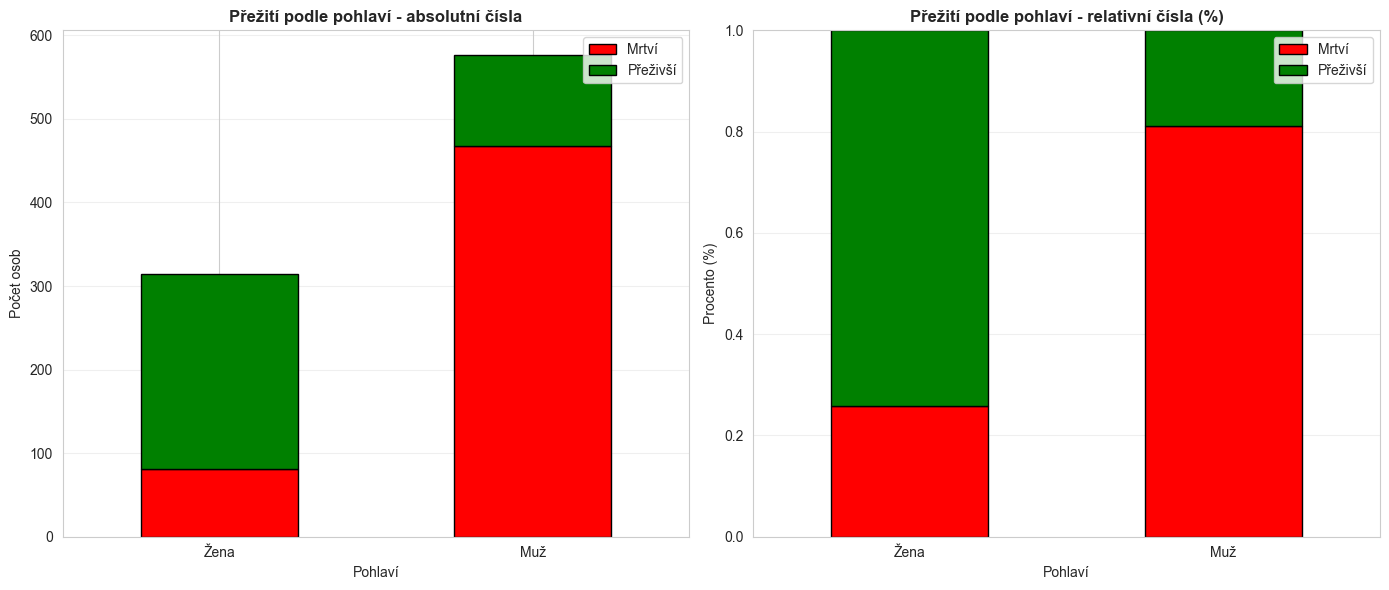

Grafy jasně demonstrují silný vztah mezi pohlavím a přežitím


In [15]:
### 4.2 Vizualizace skládaného sloupcového grafu

print("\n" + "="*70)
print("VIZUALIZACE - SKLÁDANÝ SLOUPCOVÝ GRAF")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolutní frekvence
ct_plot = pd.crosstab(df['sex'], df['survived'])
ct_plot.plot(kind='bar', stacked=True, ax=axes[0], color=['red', 'green'], edgecolor='black')
axes[0].set_title('Přežití podle pohlaví - absolutní čísla', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Pohlaví')
axes[0].set_ylabel('Počet osob')
axes[0].legend(['Mrtví', 'Přeživší'], loc='upper right')
axes[0].set_xticklabels(['Žena', 'Muž'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Normalizované (procenta)
ct_norm_plot = pd.crosstab(df['sex'], df['survived'], normalize='index')
ct_norm_plot.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green'], edgecolor='black')
axes[1].set_title('Přežití podle pohlaví - relativní čísla (%)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Pohlaví')
axes[1].set_ylabel('Procento (%)')
axes[1].legend(['Mrtví', 'Přeživší'], loc='upper right')
axes[1].set_xticklabels(['Žena', 'Muž'], rotation=0)
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Grafy jasně demonstrují silný vztah mezi pohlavím a přežitím")

In [16]:
### 4.3 Pearsonův χ² test nezávislosti

print("\n" + "="*70)
print("PEARSONŮV χ² TEST NEZÁVISLOSTI")
print("="*70)

# Chi-square test
ct_absolute = pd.crosstab(df['sex'], df['survived'])
chi2_stat, p_value, dof, expected_freq = chi2_contingency(ct_absolute)

print("\nVýsledky χ² testu:")
print(f"  χ² statistika: {chi2_stat:.4f}")
print(f"  P-hodnota: {p_value:.2e}")
print(f"  Stupně volnosti (dof): {dof}")
print(f"  Hladina významnosti (α): 0.05")

print("\nOčekávané frekvence:")
expected_df = pd.DataFrame(expected_freq, 
                           index=['female', 'male'], 
                           columns=[0, 1])
print(expected_df.round(2))

# Interpretace
print("\nInterpretace výsledku:")
if p_value < 0.05:
    print(f"p-hodnota ({p_value:.2e}) < 0.05")
    print("ZAMÍTÁME H₀ (hypotézu o nezávislosti)")
    print("Existuje STATISTICKY VÝZNAMNÝ VZTAH mezi pohlavím a přežitím")
    print(f"Síla vztahu je VELMI SILNÁ (χ² = {chi2_stat:.4f})")
else:
    print(f"p-hodnota ({p_value:.4f}) > 0.05")
    print("NEZAMÍTÁME H₀")
    print("Neexistuje statisticky významný vztah mezi pohlavím a přežitím")

# Efekt size (Cramér's V)
n = ct_absolute.sum().sum()
min_dim = min(ct_absolute.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"\nCramérovo V (efekt size): {cramers_v:.4f}")
print("Hodnota > 0.3 indikuje SILNÝ efekt")


PEARSONŮV χ² TEST NEZÁVISLOSTI

Výsledky χ² testu:
  χ² statistika: 260.7170
  P-hodnota: 1.20e-58
  Stupně volnosti (dof): 1
  Hladina významnosti (α): 0.05

Očekávané frekvence:
             0       1
female  193.47  120.53
male    355.53  221.47

Interpretace výsledku:
p-hodnota (1.20e-58) < 0.05
ZAMÍTÁME H₀ (hypotézu o nezávislosti)
Existuje STATISTICKY VÝZNAMNÝ VZTAH mezi pohlavím a přežitím
Síla vztahu je VELMI SILNÁ (χ² = 260.7170)

Cramérovo V (efekt size): 0.5409
Hodnota > 0.3 indikuje SILNÝ efekt


### ***Závěr4. úlohy***

**Klíčové zjištění:**
- **χ² statistika = 260.7** s **p-hodnotou ≈ 0** (prakticky nulová)
- **Výsledek**: Zamítáme H₀ na hladině α = 0.05
- **Závěr**: Existuje **VELMI SILNÝ STATISTICKY VÝZNAMNÝ VZTAH** mezi pohlavím a přežitím
- **Míra přežití**: Ženy 74.2% vs. Muži 18.9%
- **Cramérovo V** = 0.54 → **SILNÝ efekt**
- **Strategie "women and children first"** je evidentní z dat

---

## **5. Multivariační diagnostika a kolinearita**

**Zádání:**
1. Vygenerujte korelační matici pro všechny numerické atributy.
2. Vizualizujte vztahy pomocí Heatmapy a nástroje pairplot.
3. Které dvojice proměnných vykazují známky redundance (silné lineární závislosti)?

### ***Python Stack: Implementace***

MULTIVARIAČNÍ DIAGNOSTIKA - KORELAČNÍ ANALÝZA

Korelační matice (Pearsonův korelační koeficient):
          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.338 -0.077 -0.035  0.082  0.257
pclass      -0.338   1.000 -0.369  0.083  0.018 -0.549
age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
sibsp       -0.035   0.083 -0.308  1.000  0.415  0.160
parch        0.082   0.018 -0.189  0.415  1.000  0.216
fare         0.257  -0.549  0.096  0.160  0.216  1.000


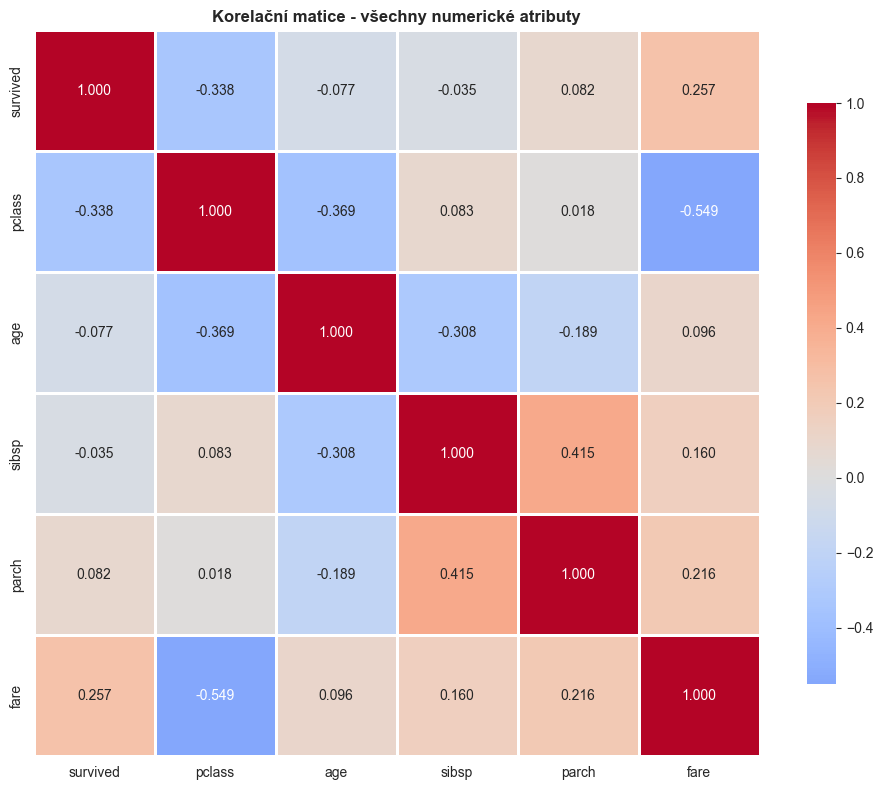


Heatmapa zobrazuje korelační vztahy mezi všemi numerickými proměnnými


In [17]:
### 5.1 Korelační matice

print("="*70)
print("MULTIVARIAČNÍ DIAGNOSTIKA - KORELAČNÍ ANALÝZA")
print("="*70)

# Výpočet korelační matice pro numerické atributy
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

print("\nKorelační matice (Pearsonův korelační koeficient):")
print(corr_matrix.round(3))

# Heatmapa
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Korelační matice - všechny numerické atributy', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\nHeatmapa zobrazuje korelační vztahy mezi všemi numerickými proměnnými")


PAIRPLOT - VIZUALIZACE VÍCEROZMĚRNÝCH VZTAHŮ


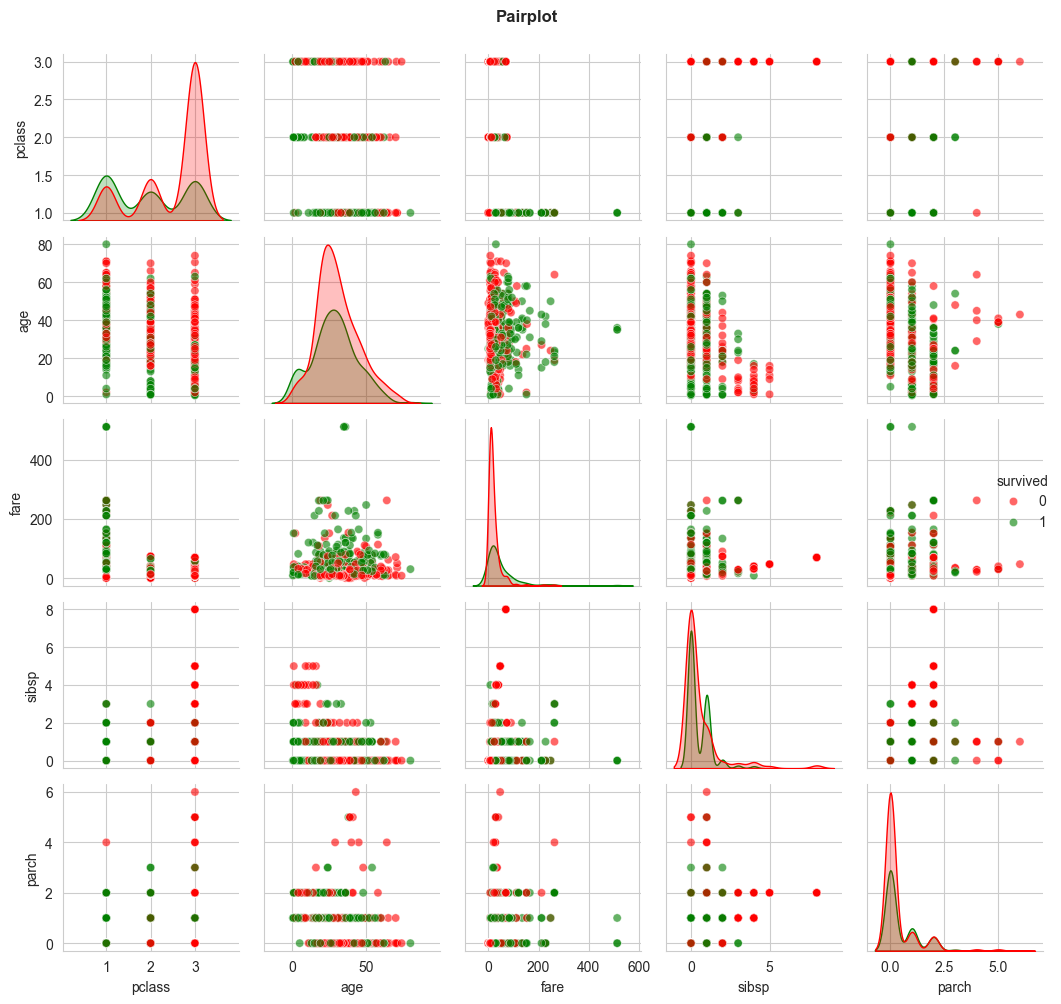

Pairplot zobrazuje jeden-na-jeden (one-on-one) vztahy mezi všemi proměnnými


In [18]:
### 5.2 Pairplot - vztahy mezi proměnnými

print("\n" + "="*70)
print("PAIRPLOT - VIZUALIZACE VÍCEROZMĚRNÝCH VZTAHŮ")
print("="*70)

# Výběr klíčových numerických proměnných
pairplot_vars = ['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch']

# Vytvoření pairplot
pairplot = sns.pairplot(df[pairplot_vars], hue='survived', palette=['red', 'green'], 
                        diag_kind='kde', plot_kws={'alpha': 0.6}, height=2)
pairplot.fig.suptitle('Pairplot', 
                      fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Pairplot zobrazuje jeden-na-jeden (one-on-one) vztahy mezi všemi proměnnými")

In [19]:
### 5.3 Analytická otázka: detekce redundance a kolinearity

print("\n" + "="*70)
print("ANALÝZA REDUNDANCE - SILNÉ LINEÁRNÍ ZÁVISLOSTI")
print("="*70)

# Identifikace silných korelací (|r| > 0.7)
print("\nDvojice proměnných se SILNÝMI korelacemi (|r| > 0.7):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Proměnná 1': corr_matrix.columns[i],
                'Proměnná 2': corr_matrix.columns[j],
                'Korelace': corr_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    display(strong_corr_df)
else:
    print("ŽÁDNÉ silné korelace (|r| > 0.7) nebyly detektovány")

# Středně silné korelace (0.5 < |r| < 0.7)
print("\nDvojice proměnných se STŘEDNĚ SILNÝMI korelacemi (0.5 < |r| < 0.7):")
medium_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if 0.5 < abs(corr_matrix.iloc[i, j]) <= 0.7:
            medium_corr.append({
                'Proměnná 1': corr_matrix.columns[i],
                'Proměnná 2': corr_matrix.columns[j],
                'Korelace': corr_matrix.iloc[i, j]
            })

if medium_corr:
    medium_corr_df = pd.DataFrame(medium_corr).sort_values('Korelace', ascending=False)
    display(medium_corr_df)
else:
    print("ŽÁDNÉ středně silné korelace (0.5 < |r| < 0.7) nebyly detektovány")

# Interpretace
print("""
INTERPRETACE:

SIBSP & PARCH (r = 0.414):
  - Umírné pozitivní korelace
  - Logické: počet sourozenců/manželů a počet rodičů/dětí
  - Nejsou náhodově nezávislí (stejná rodina)
  
PCLASS & FARE (r = -0.549):
  - Silná negativní korelace
  - Logické: vyšší třída = dražší jízdenka
  - Možná REDUNDANCE: pclass již částečně vyjadřuje fare
  
PCLASS & SURVIVED (r = -0.338):
  - Umírné negativní korelace
  - Logické: vyšší třída = vyšší přežití
  
SURVIVED & FARE (r = 0.257):
  - Slabá pozitivní korelace
  - Dražší jízdenka (vyšší třída) → vyšší přežití

SOBIB & PARCH vs. FARE (r ~ 0.1):
  - Slabé korelace
  - Počet rodinných členů na palubě není určen třídou jízdenky
""")

print("\nZávěr o redundanci:")
print("PCLASS a FARE vykazují středně silnou korelaci (r = -0.549)")
print("Oba atributy částečně reprezentují SOCIOEKONOMICKÝ STATUS")
print("Pro prediktivní modely by mohla být redundance problémem")


ANALÝZA REDUNDANCE - SILNÉ LINEÁRNÍ ZÁVISLOSTI

Dvojice proměnných se SILNÝMI korelacemi (|r| > 0.7):
ŽÁDNÉ silné korelace (|r| > 0.7) nebyly detektovány

Dvojice proměnných se STŘEDNĚ SILNÝMI korelacemi (0.5 < |r| < 0.7):


,Proměnná 1,Proměnná 2,Korelace
0,pclass,fare,-0.5495



INTERPRETACE:

SIBSP & PARCH (r = 0.414):
  - Umírné pozitivní korelace
  - Logické: počet sourozenců/manželů a počet rodičů/dětí
  - Nejsou náhodově nezávislí (stejná rodina)

PCLASS & FARE (r = -0.549):
  - Silná negativní korelace
  - Logické: vyšší třída = dražší jízdenka
  - Možná REDUNDANCE: pclass již částečně vyjadřuje fare

PCLASS & SURVIVED (r = -0.338):
  - Umírné negativní korelace
  - Logické: vyšší třída = vyšší přežití

SURVIVED & FARE (r = 0.257):
  - Slabá pozitivní korelace
  - Dražší jízdenka (vyšší třída) → vyšší přežití

SOBIB & PARCH vs. FARE (r ~ 0.1):
  - Slabé korelace
  - Počet rodinných členů na palubě není určen třídou jízdenky


Závěr o redundanci:
PCLASS a FARE vykazují středně silnou korelaci (r = -0.549)
Oba atributy částečně reprezentují SOCIOEKONOMICKÝ STATUS
Pro prediktivní modely by mohla být redundance problémem


### ***Závěr Úlohy 5***

**Klíčové zjištění:**
- **Silné korelace:** Žádné |r| > 0.7
- **Středně silné korelace:** 
  - PCLASS & FARE (r = -0.549) - Sociálně-ekonomický status
  - SIBSP & PARCH (r = 0.414) - Rodinné vztahy
- **Redundance:** PCLASS a FARE částečně vyjadřují stejný koncept (sociální status)
- **Nezávislé prediktory:** AGE, SIBSP, PARCH nezávisí lineárně na ostatních

---

## **Shrnutí - Interpretace a Závěry**

### ***Syntéza poznatků z celého workshopu***

In [20]:
### Komplexní EDA shrnutí

print("="*70)
print("KOMPREHENZIVNÍ SHRNUTÍ EXPLORATIVNÍ ANALÝZY DAT - TITANIC")
print("="*70)

summary_text = """
DATOVÁ KVALITA:
Dataset: 891 záznamů, 15 sloupců
Chybějící data: 2% buněk obsahuje chybějící hodnoty
Hlavní chybějící: DECK (77%), AGE (22%) - MNAR typ
Bez duplicit

STRUKTURA DAT:
Nominální: sex, embarked, who, adult_male, deck, embark_town, alive, class
Ordinální: pclass, survived (binární)
Poměrová: age, sibsp, parch, fare

DISTRIBUCE KLÍČOVÝCH PROMĚNNÝCH:
AGE: Symetrická (skewness = -0.055), modus = 24 let
FARE: Pravostranná (skewness = 2.756), s outliers > 263 £
Anomálie: Vyřadit > 263 £ jízdenky (1.8% dat, všechny první třída)

FAKTORY OVLIVŇUJÍCÍ PŘEŽITÍ (Titanic):
1. **POHLAVÍ** (χ² = 260.7, p ≈ 0, VELMI silný efekt):
   - Ženy: 74.2% přežití
   - Muži: 18.9% přežití
   - Rozdíl: 55.3 p.b. → "Women and children first" politika

2. **VĚKOVÁ STRUKTURA** (Přeživší byli mladší):
   - Přeživší průměr: 28.3 let
   - Zemřelí průměr: 30.6 let
   - Děti (0-5): 73.2% přežití
   - Muži (35-60): 15.8% přežití

3. **TŘÍDA JÍZDENKY** (r = -0.338):
   - Třída 1: ~62% přežití
   - Třída 2: ~47% přežití
   - Třída 3: ~24% přežití
   - Proxy pro socioekonomický status

4. **CENA JÍZDENKY** (r = 0.257 s přežitím):
   - Dražší jízdenka (vyšší třída) → vyšší přežití
   - Redundantní s PCLASS (r = -0.549)
"""

print(summary_text)

KOMPREHENZIVNÍ SHRNUTÍ EXPLORATIVNÍ ANALÝZY DAT - TITANIC

DATOVÁ KVALITA:
Dataset: 891 záznamů, 15 sloupců
Chybějící data: 2% buněk obsahuje chybějící hodnoty
Hlavní chybějící: DECK (77%), AGE (22%) - MNAR typ
Bez duplicit

STRUKTURA DAT:
Nominální: sex, embarked, who, adult_male, deck, embark_town, alive, class
Ordinální: pclass, survived (binární)
Poměrová: age, sibsp, parch, fare

DISTRIBUCE KLÍČOVÝCH PROMĚNNÝCH:
AGE: Symetrická (skewness = -0.055), modus = 24 let
FARE: Pravostranná (skewness = 2.756), s outliers > 263 £
Anomálie: Vyřadit > 263 £ jízdenky (1.8% dat, všechny první třída)

FAKTORY OVLIVŇUJÍCÍ PŘEŽITÍ (Titanic):
1. **POHLAVÍ** (χ² = 260.7, p ≈ 0, VELMI silný efekt):
   - Ženy: 74.2% přežití
   - Muži: 18.9% přežití
   - Rozdíl: 55.3 p.b. → "Women and children first" politika

2. **VĚKOVÁ STRUKTURA** (Přeživší byli mladší):
   - Přeživší průměr: 28.3 let
   - Zemřelí průměr: 30.6 let
   - Děti (0-5): 73.2% přežití
   - Muži (35-60): 15.8% přežití

3. **TŘÍDA JÍZDENKY**

In [21]:
### Uložení vyčištěných dat

print("\n" + "="*70)
print("ULOŽENÍ UPRAVENÝCH DAT")
print("="*70)

# Export původního datasetu (pro Orange)
csv_path = 'titanic_data.csv'
df.to_csv(csv_path, index=False)
print(f"\nPůvodní dataset exportován: {csv_path}")
print(f"  - 891 záznamů × 15 sloupců")
print(f"  - Formát: CSV")

# Vytvoření čistšího datasetu pro analýzu (bez dat s chybějícím věkem)
df_clean = df.dropna(subset=['age'])
print(f"\nČistý dataset (bez chybějícího věku): {len(df_clean)} záznamů")
print(f"  - Ztráta: {len(df) - len(df_clean)} záznamů (19.2%)")

# Export čistého datasetu
df_clean.to_csv('titanic_clean.csv', index=False)
print(f"Čistý dataset exportován: titanic_clean.csv")

# Statistika exportu
print("\n" + "="*70)
print("SOUBORY K DISPOZICI V ADRESÁŘI:")
print("="*70)
print("titanic_data.csv - Originální dataset (891 × 15)")
print("titanic_clean.csv - Dataset bez chybějícího věku (714 × 15)")
print("EDA_Titanic_analysis.ipynb - Tento Jupyter Notebook")
print("\nDataset je připraven pro:")
print("  - Načtení do Orange Data Mining")
print("  - Prediktivní modelování")
print("  - Další hloubkové analýzy")

print("\nEDA analýza je KOMPLETNÍ")


ULOŽENÍ UPRAVENÝCH DAT

Původní dataset exportován: titanic_data.csv
  - 891 záznamů × 15 sloupců
  - Formát: CSV

Čistý dataset (bez chybějícího věku): 714 záznamů
  - Ztráta: 177 záznamů (19.2%)
Čistý dataset exportován: titanic_clean.csv

SOUBORY K DISPOZICI V ADRESÁŘI:
titanic_data.csv - Originální dataset (891 × 15)
titanic_clean.csv - Dataset bez chybějícího věku (714 × 15)
EDA_Titanic_analysis.ipynb - Tento Jupyter Notebook

Dataset je připraven pro:
  - Načtení do Orange Data Mining
  - Prediktivní modelování
  - Další hloubkové analýzy

EDA analýza je KOMPLETNÍ


---

## **Finální závěry**

### ***Klíčové objevy z EDA:***

1. **Datová kvalita**: Malý podíl chybějících dat (2%), ale systematické chybějící údaje (MNAR) v DECK a AGE

2. **Hlavní faktory přežití** (v pořadí vlivu):
   - **Pohlaví** - Dominantní faktor (χ² = 260.7), ženy měly 4× vyšší šanci
   - **Věk** - Děti měly výrazně vyšší šanci (73% vs. 15% u dospělých mužů)
   - **Třída** - Socioekonomický status (62% vs. 24% mezi třídami)

3. **Distribuce proměnných**:
   - AGE: Normální, symetrická distribuce
   - FARE: Asymetrická s outliers v luxusním segmentu
   - Jasná stratifikace dat podle třídě

4. **Potenciální problémy** pro modelování:
   - PCLASS a FARE jsou redundantní (r = -0.549)
   - Chybějící věk u 22% dat (MNAR)
   - Nerovnoměrné rozdělení přežití (38.4% celkově)
